<a href="https://colab.research.google.com/github/nev12/gym-dropout-prediction/blob/main/03_eda_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PREDICTION OF GYM MEMBER DROPOUT


**OBJECTIVE**
- The objective of this notebook is to explore historical engagement features derived from the validated synthetic dataset and evaluate their usefulness for predicting user churn. The analysis focuses on identifying which features provide signal beyond the churn definition itself and building a leakage-free baseline model.


**DATASET**
- The modeling dataset consists of user-level aggregated engagement features, including total activity volume, engagement frequency, and session-level averages. The target variable indicates whether a user has been inactive for at least 21 days following their most recent check-in.
- Data is generated


**CHURN DEFINITION**
- Churn is operationally defined as a period of inactivity of 21 days or longer since a user’s last recorded check-in. This threshold was selected based on prior validation of inactivity distributions and yields a non-trivial class balance suitable for modeling.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [2]:
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(
    filename,
    parse_dates=["first_checkin", "last_checkin"],
    dtype={
        "user_id": "string",
        "active_days": "int64",
        "average_training_duratation": "float64",
        "avg_calories_burned": "float64",
        "workout_type_count": "int64",
        "days_since_last_checkin": "int64",
        "churned": "int64"
    }
)

original_len = len(df)
df.head()

Saving user_features.csv to user_features.csv


,user_id,active_days,first_checkin,last_checkin,avg_training_duratation,avg_calories_burned,workout_type_count,days_since_last_checkin,churned
0,user_1,40,2025-03-10 13:34:25,2025-12-23 19:18:23,91.4500,727.2500,1,7,0
1,user_10,32,2025-03-16 20:06:32,2025-12-30 12:40:38,85.9688,689.5625,2,0,0
2,user_100,103,2025-02-06 04:29:27,2025-12-29 04:51:32,92.3398,739.1068,2,1,0
3,user_1000,53,2025-01-12 01:16:56,2025-12-16 12:26:58,90.0189,713.9057,1,14,0
4,user_1001,70,2025-01-15 20:31:41,2025-08-16 21:50:33,88.0429,719.3143,2,136,1


## EXPLORATORY DATA ANALYSIS


### 1. Churn distribution:

Text(0.5, 1.0, 'Churn distribution')

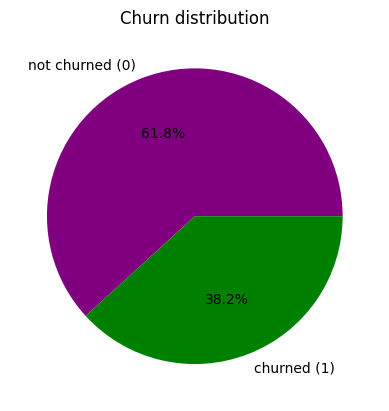

In [3]:
plt.pie(df["churned"].value_counts(),
        colors=["purple", "green"],
        labels=["not churned (0)", "churned (1)"],
        autopct="%1.1f%%")
plt.title("Churn distribution")

- The target variable shows a positive class rate of 38.2%, indicating a moderately balanced dataset. This distribution is beneficial for churn prediction because it avoids strong class imbalance and allows the model to be evaluated using standard metrics.

### 2. Parameter difference between churned and not churned users:

Text(0, 0.5, 'number of users')

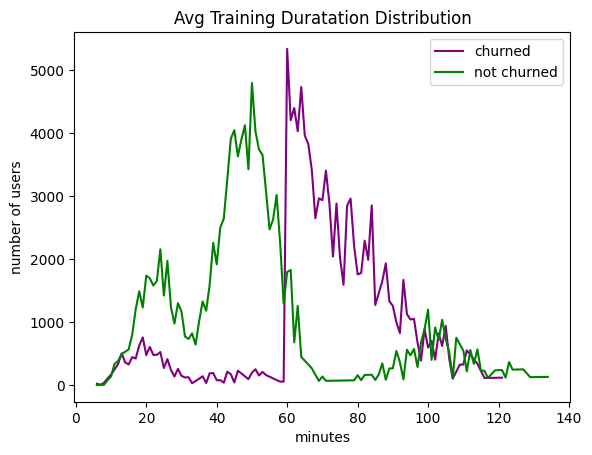

In [4]:
churned = df[df["churned"] == 1].sort_values("active_days", ascending=False)
not_churned = df[df["churned"] == 0].sort_values("active_days", ascending=False)

plt.plot(churned.groupby("active_days")["active_days"].sum(),
         color="purple",
         label="churned")
plt.plot(not_churned.groupby("active_days")["active_days"].sum(),
         color="green",
         label="not churned")
plt.title("Avg Training Duratation Distribution")
plt.legend()
plt.xlabel("minutes")
plt.ylabel("number of users")

Text(0, 0.5, 'number of users')

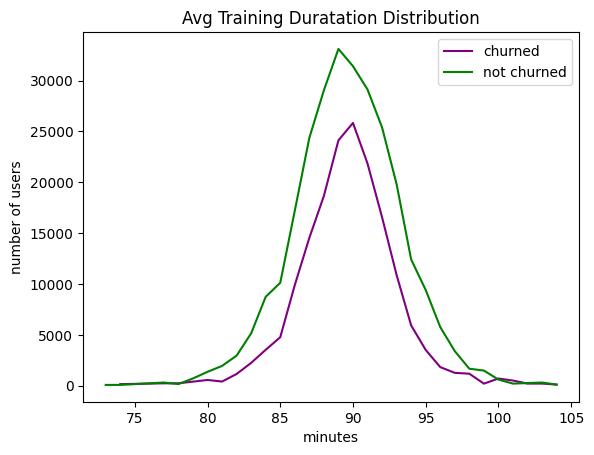

In [5]:
churned = churned.sort_values("avg_training_duratation")
not_churned = not_churned.sort_values("avg_training_duratation")

churned["avg_training_duratation"] = churned["avg_training_duratation"].round()
not_churned["avg_training_duratation"] = not_churned["avg_training_duratation"].round()

plt.plot(churned.groupby("avg_training_duratation")["avg_training_duratation"].sum(),
         color="purple",
         label="churned")
plt.plot(not_churned.groupby("avg_training_duratation")["avg_training_duratation"].sum(),
         color="green",
         label="not churned")
plt.title("Avg Training Duratation Distribution")
plt.legend()
plt.xlabel("minutes")
plt.ylabel("number of users")

In [6]:
churned_counts = (churned["workout_type_count"]
                  .value_counts()
                  .rename("churned"))
not_churned_counts = (not_churned["workout_type_count"]
                  .value_counts()
                  .rename("not churned"))

pd.concat([churned_counts, not_churned_counts], axis=1).fillna(0).astype(int)

,churned,not churned
workout_type_count,,
1,960,1544
2,951,1545


Text(0, 0.5, 'number of users')

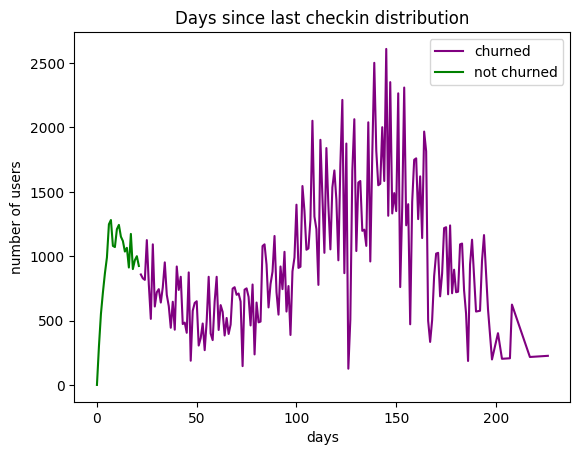

In [7]:
churned = churned.sort_values("days_since_last_checkin")
not_churned = not_churned.sort_values("days_since_last_checkin")

plt.plot(churned.groupby("days_since_last_checkin")["days_since_last_checkin"].sum(),
         color="purple",
         label="churned")
plt.plot(not_churned.groupby("days_since_last_checkin")["days_since_last_checkin"].sum(),
         color="green",
         label="not churned")
plt.title("Days since last checkin distribution")
plt.legend()
plt.xlabel("days")
plt.ylabel("number of users")

- The exploratory analysis compares historical engagement features between churned and active users. Recency-based variables show strong differences, but are excluded from modeling to avoid target leakage. Other engagement features show limited separation on their own, suggesting weaker predictive power without recency information.

## BUILDING THE MODEL



In [8]:
features = [
    "active_days",
    "avg_training_duratation",
    "avg_calories_burned",
    "workout_type_count"
]

X = df[features]
y = df["churned"]

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [9]:
model = LogisticRegression(max_iter = 1000,
                           class_weight = 'balanced',
                           random_state=42)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [10]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

In [11]:
print(classification_report(y_test, y_pred))
print("ROC AUC: ", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.81      0.72      0.76       618
           1       0.61      0.73      0.67       382

    accuracy                           0.72      1000
   macro avg       0.71      0.72      0.71      1000
weighted avg       0.74      0.72      0.72      1000

ROC AUC:  0.7344795743743541


In [12]:
coef_df = pd.DataFrame({
    'features': features,
    'coefficient': model.coef_[0]
})

coef_df

,features,coefficient
0,active_days,0.743206
1,avg_training_duratation,0.037461
2,avg_calories_burned,0.030034
3,workout_type_count,-0.002287


**MODEL APPROACH**
- A baseline logistic regression model was trained using historical engagement features only. Recency-related variables were excluded to avoid target leakage, since churn is defined based on inactivity. All features were standardized before training, and class imbalance was handled using class weights.


**MODEL PERFORMANCE**
- The model shows modest performance, which is expected since historical engagement features alone provide limited information for predicting churn without recency data. The results therefore represent a realistic baseline rather than an optimized model.



## CONCLUSION


- This notebook shows a full churn modeling workflow on synthetic data while avoiding target leakage. The model performance is limited but expected, and the results emphasize the importance of careful feature selection and evaluation.
